<a href="https://colab.research.google.com/github/bhavithamedakayala33-hash/Customer-Churn-Prediction/blob/main/CUSTOMER_CHURN_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction Using Machine Learning

## Project Objective

The objective of this project is to predict whether a customer is likely to leave a telecom company using machine learning. This helps businesses identify high-risk customers and improve customer retention.

## Import Libraries

In this section, we import the required Python libraries for data manipulation, visualization, and machine learning.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## Load Dataset

The Telco Customer Churn dataset is loaded into a Pandas DataFrame for further analysis.

In [35]:
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv.csv"

df = pd.read_csv(file_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Preprocessing

The dataset is cleaned by converting the TotalCharges column into numeric format and removing missing values.

In [36]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].str.strip(),
    errors='coerce'
)

df = df.dropna().reset_index(drop=True)

df['Churn_Numeric'] = df['Churn'].apply(
    lambda x: 1 if x == 'Yes' else 0
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Numeric
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## Feature Selection

The important features required for predicting customer churn are selected.

In [37]:
feature_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Contract',
    'InternetService',
    'PaymentMethod'
]

X = df[feature_cols].copy()

## Label Encoding

Categorical columns are converted into numerical values so that the machine learning algorithm can process them.

In [38]:
encoders = {}

for col in ['Contract', 'InternetService', 'PaymentMethod']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

X.head()

,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod
0,1,29.85,29.85,0,0,2
1,34,56.95,1889.50,1,0,3
2,2,53.85,108.15,0,0,3
3,45,42.30,1840.75,1,0,0
4,2,70.70,151.65,0,1,2


## Train-Test Split

The dataset is divided into training and testing sets. The model is trained on the training data and evaluated on unseen testing data to measure its performance.

In [39]:
# Target variable
y = df["Churn_Numeric"]

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 5625
Testing samples : 1407


## Model Training

A Random Forest Classifier is trained using the selected customer features to predict churn.

In [40]:
# Train the Random Forest model
model = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [41]:
# Predict on taesting data
y_pred = model.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy :", round(accuracy*100,2),"%")

Model Accuracy : 75.91 %


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1033
           1       0.55      0.49      0.52       374

    accuracy                           0.76      1407
   macro avg       0.69      0.67      0.68      1407
weighted avg       0.75      0.76      0.75      1407



## Model Evaluation

The trained Random Forest model is evaluated using the testing dataset. Various evaluation metrics are used to measure the model's prediction performance.

## Model Evaluation

The trained model is evaluated using the testing dataset. Metrics such as Accuracy, Confusion Matrix, and Classification Report are used to measure its performance.

In [44]:
# Predict on testing data
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

# Classification Report
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy: 75.91 %

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1033
           1       0.55      0.49      0.52       374

    accuracy                           0.76      1407
   macro avg       0.69      0.67      0.68      1407
weighted avg       0.75      0.76      0.75      1407



Confusion Matrix

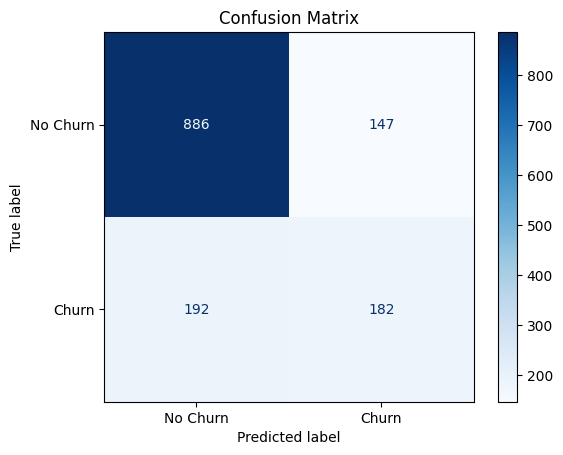

In [45]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

## Risk Score Prediction

The trained model predicts the probability of each customer leaving the company. This probability is stored as a risk score.

In [46]:
df['Risk_Score'] = model.predict_proba(X)[:, 1]

df[['customerID', 'Risk_Score']].head()

,customerID,Risk_Score
0,7590-VHVEG,0.351667
1,5575-GNVDE,0.000000
2,3668-QPYBK,0.743333
3,7795-CFOCW,0.010000
4,9237-HQITU,0.850000


## Customer Churn Dashboard

A dashboard is created to visualize customer churn trends, feature importance, contract-based churn analysis, and financial exposure.

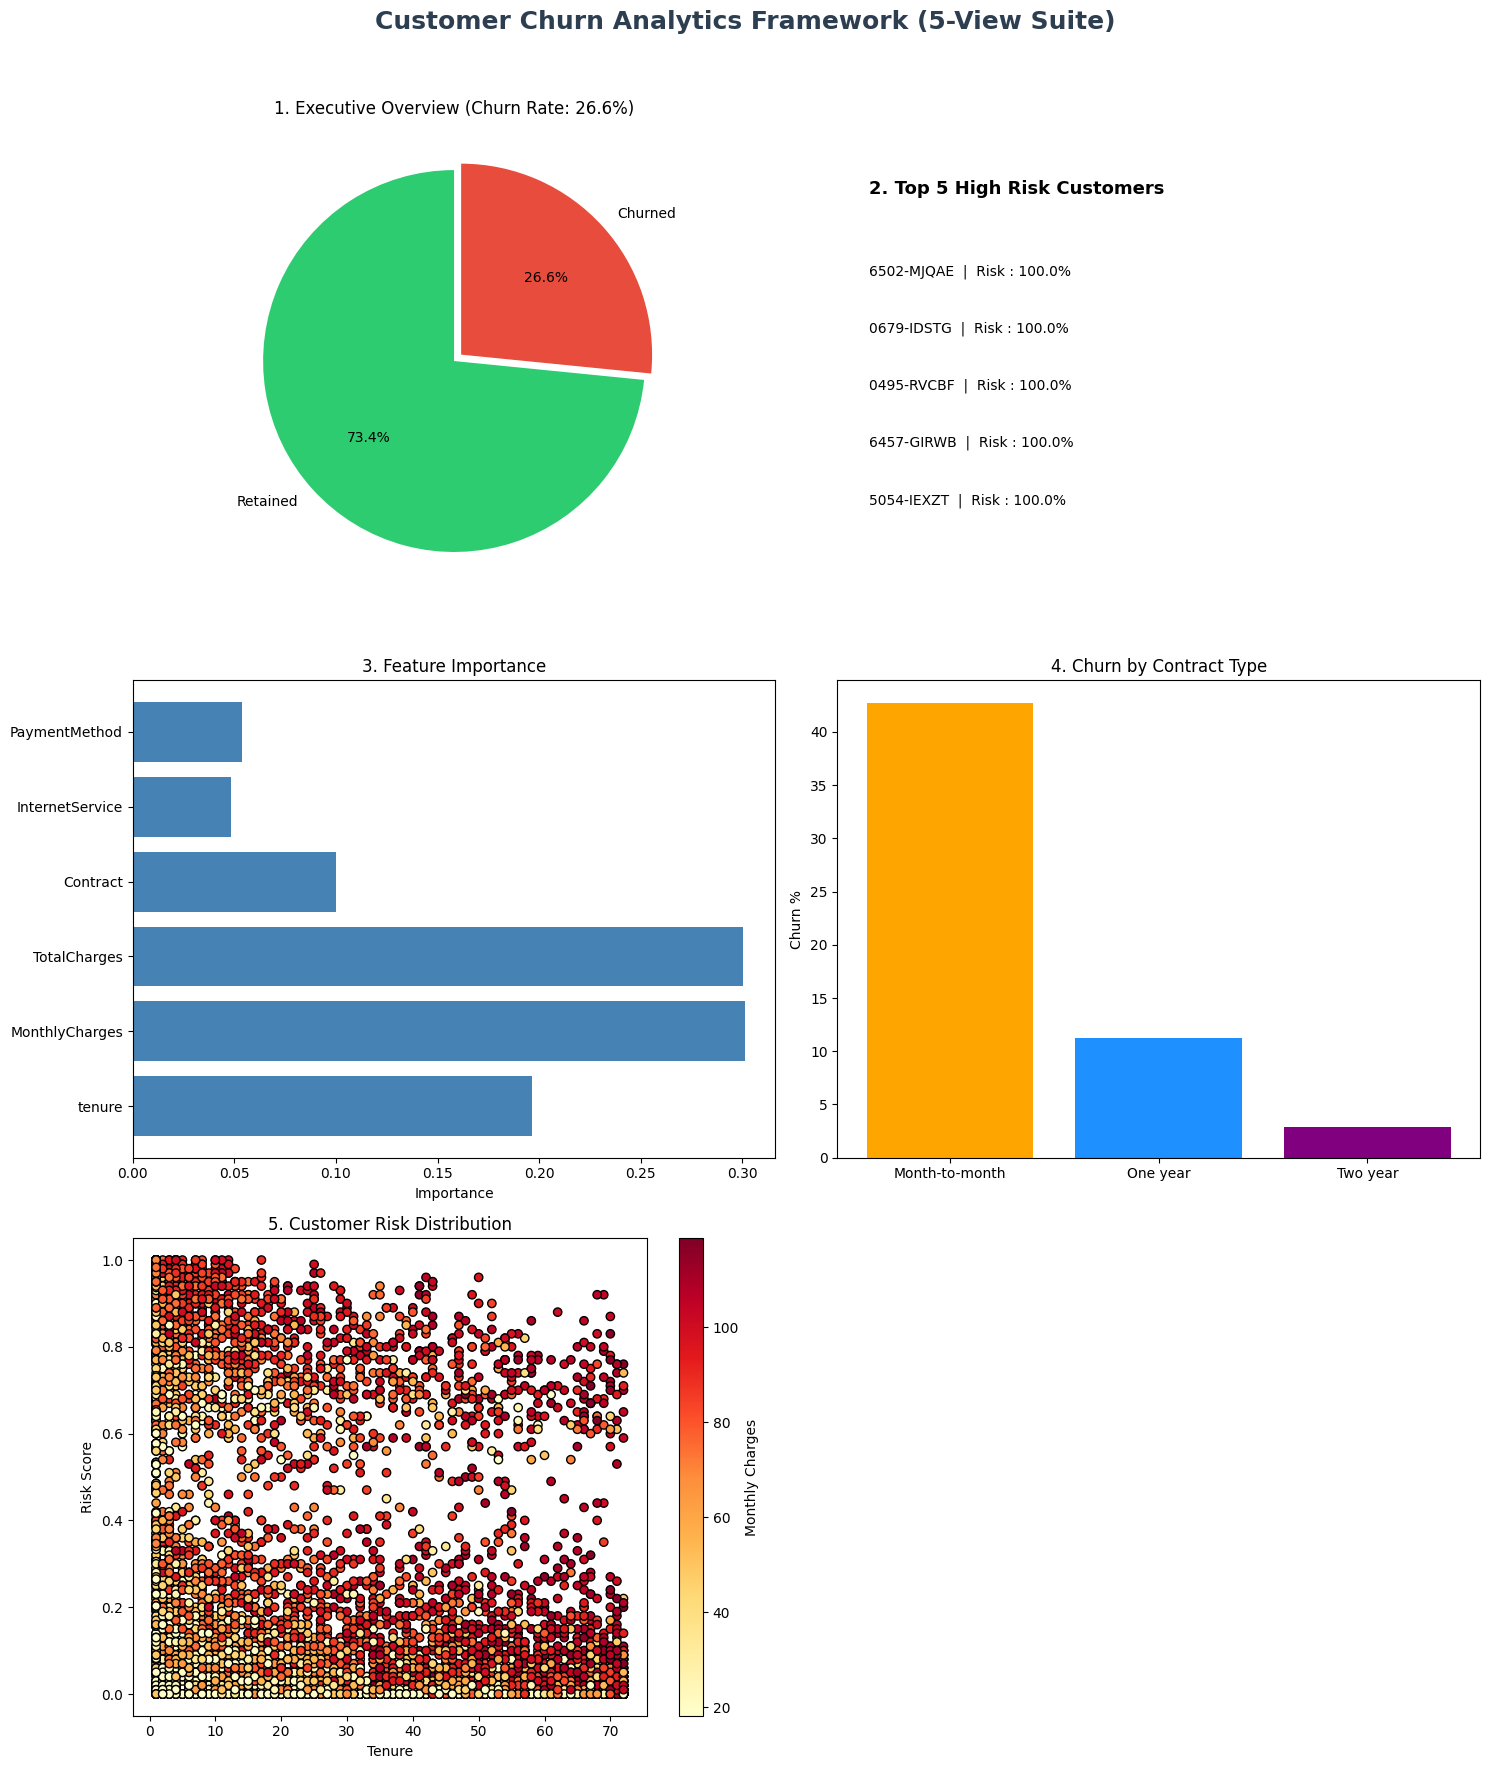

In [47]:
# ----------------------------------------------------------------------------
# CUSTOMER CHURN DASHBOARD
# ----------------------------------------------------------------------------

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.suptitle(
    "Customer Churn Analytics Framework (5-View Suite)",
    fontsize=18,
    fontweight='bold',
    color='#2c3e50'
)

# ---------------------------
# View 1 : Churn Overview
# ---------------------------
churn_rate = df['Churn_Numeric'].mean() * 100
counts = df['Churn_Numeric'].value_counts()

axes[0,0].pie(
    counts,
    labels=['Retained','Churned'],
    autopct='%1.1f%%',
    colors=['#2ecc71','#e74c3c'],
    explode=(0,0.05),
    startangle=90
)

axes[0,0].set_title(
    f"1. Executive Overview (Churn Rate: {churn_rate:.1f}%)"
)

# ---------------------------
# View 2 : High Risk Customers
# ---------------------------
high_risk = df[df['Risk_Score']>0.75].sort_values(
    by='Risk_Score',
    ascending=False
).head(5)

axes[0,1].axis('off')

axes[0,1].text(
    0.05,
    0.85,
    "2. Top 5 High Risk Customers",
    fontsize=13,
    fontweight='bold'
)

y = 0.68

for _, row in high_risk.iterrows():

    axes[0,1].text(
        0.05,
        y,
        f"{row['customerID']}  |  Risk : {row['Risk_Score']*100:.1f}%",
        fontsize=10
    )

    y -= 0.12

# ---------------------------
# View 3 : Feature Importance
# ---------------------------
importances = model.feature_importances_

axes[1,0].barh(feature_cols, importances, color='steelblue')

axes[1,0].set_title("3. Feature Importance")

axes[1,0].set_xlabel("Importance")

# ---------------------------
# View 4 : Contract Analysis
# ---------------------------
contract_churn = df.groupby("Contract")["Churn_Numeric"].mean()*100

axes[1,1].bar(
    contract_churn.index.astype(str),
    contract_churn.values,
    color=['orange','dodgerblue','purple']
)

axes[1,1].set_ylabel("Churn %")

axes[1,1].set_title("4. Churn by Contract Type")

# ---------------------------
# View 5 : Risk Distribution
# ---------------------------
at_risk = df[df["Risk_Score"]>0.60]

scatter = axes[2,0].scatter(
    df["tenure"],
    df["Risk_Score"],
    c=df["MonthlyCharges"],
    cmap="YlOrRd",
    edgecolors="black"
)

axes[2,0].set_xlabel("Tenure")

axes[2,0].set_ylabel("Risk Score")

axes[2,0].set_title("5. Customer Risk Distribution")

fig.colorbar(
    scatter,
    ax=axes[2,0],
    label="Monthly Charges"
)

# Last subplot empty
axes[2,1].axis("off")

plt.tight_layout(rect=[0,0,1,0.96])

plt.show()

# Conclusion

This project successfully predicts customer churn using the Random Forest Classifier. It identifies high-risk customers, analyzes important factors affecting churn, and provides visual insights through an analytics dashboard. The project demonstrates the complete machine learning workflow from data preprocessing to prediction and visualization.